# Riesgo financiero de empresas
## Pregunta de negocio: que empresas muestran senales de riesgo?

Calculamos ratios financieros y un score de riesgo compuesto (0-100) para priorizar revision de credito o cartera.

**Autor:** Pablo Morales | **Datos:** sinteticos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
pd.set_option("display.max_columns", None)

## 1. Cargar estados financieros

In [2]:
df = pd.read_csv("data/estados_financieros.csv")
print(f"Empresas: {df.empresa.nunique()} | Anios: {sorted(df.anio.unique())}")
df.head()

Empresas: 20 | Anios: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


,empresa,sector,anio,ingresos,costos,utilidad_neta,activo_corriente,pasivo_corriente,activo_total,deuda_total,patrimonio
0,Empresa A,Retail,2022,27480585419,22905486312,4575099108,10253585420,6159955418,36695038427,13524082870,23170955557
1,Empresa A,Retail,2023,28936499194,25797252092,3139247101,7330904383,4241593178,23609914194,8276745947,15333168248
2,Empresa A,Retail,2024,31960194025,28486461321,3473732704,13181284285,8143108251,41089887887,14766592039,26323295848
3,Empresa A,Retail,2025,35789470778,31419288010,4370182768,10408394782,5760491223,49186466188,15435959843,33750506345
4,Empresa B,Retail,2022,33151149574,30205124611,2946024963,7936171217,3707264080,29003798136,10027761925,18976036212


## 2. Ratios del ultimo anio por empresa

In [3]:
ult = df.sort_values("anio").groupby("empresa").tail(1).copy()
ult["margen_neto"] = ult.utilidad_neta / ult.ingresos
ult["liquidez"] = ult.activo_corriente / ult.pasivo_corriente
ult["endeudamiento"] = ult.deuda_total / ult.activo_total
ult["roe"] = ult.utilidad_neta / ult.patrimonio
ult[["empresa","sector","margen_neto","liquidez","endeudamiento","roe"]].head()

,empresa,sector,margen_neto,liquidez,endeudamiento,roe
31,Empresa H,Tecnología,0.063864,1.216247,0.620375,0.132351
27,Empresa G,Retail,0.095023,2.106153,0.339775,0.143411
19,Empresa E,Tecnología,0.088573,1.447424,0.518240,0.220248
23,Empresa F,Retail,0.045585,1.334492,0.470971,0.076096
63,Empresa P,Tecnología,0.080507,1.450331,0.614789,0.158778


## 3. Score de riesgo compuesto (0-100)
Cada dimension aporta hasta 25 puntos: baja liquidez, alto endeudamiento, margen negativo y decrecimiento suman riesgo.

In [4]:
def score(r):
    s = 0.0
    s += max(0, min(25, (1.5 - r.liquidez) / 1.5 * 25))
    s += max(0, min(25, (r.endeudamiento - 0.4) / 0.4 * 25))
    s += max(0, min(25, (0.08 - r.margen_neto) / 0.15 * 25))
    return round(max(0, min(100, s)))

ult["score_riesgo"] = ult.apply(score, axis=1)
rank = ult.sort_values("score_riesgo", ascending=False)
rank[["empresa","sector","liquidez","endeudamiento","margen_neto","score_riesgo"]].head(10)

,empresa,sector,liquidez,endeudamiento,margen_neto,score_riesgo
51,Empresa M,Tecnología,0.840364,0.865259,-0.017252,52
39,Empresa J,Manufactura,1.031553,0.827628,-0.025340,50
31,Empresa H,Tecnología,1.216247,0.620375,0.063864,21
47,Empresa L,Servicios,1.168376,0.620251,0.083971,19
55,Empresa N,Servicios,1.181844,0.622643,0.080464,19
15,Empresa D,Manufactura,1.237668,0.591395,0.091548,16
75,Empresa S,Servicios,1.282333,0.510426,0.052177,15
59,Empresa O,Manufactura,1.304358,0.540395,0.060046,15
11,Empresa C,Retail,1.201185,0.543211,0.093215,14
43,Empresa K,Retail,1.168017,0.489085,0.060679,14


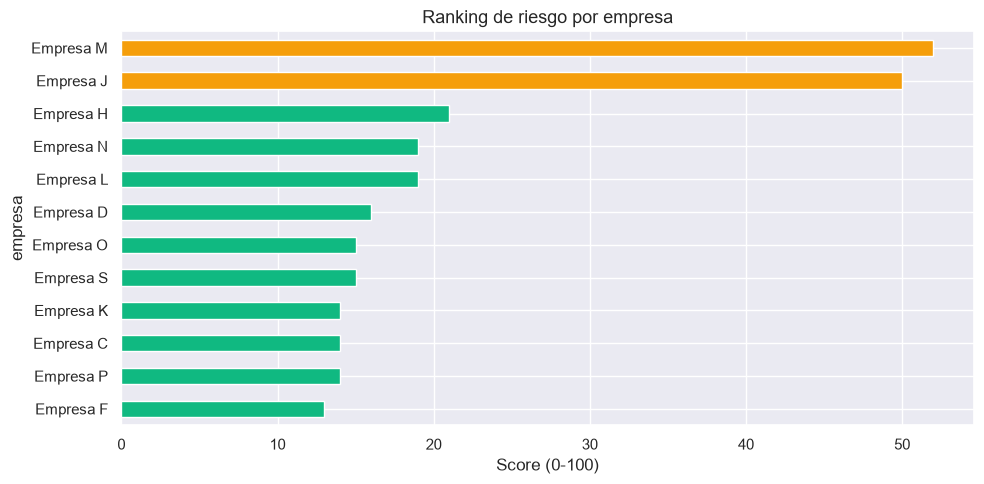

In [5]:
top = rank.head(12).sort_values("score_riesgo")
colores = ["#f43f5e" if s>=65 else "#f59e0b" if s>=50 else "#10b981" for s in top.score_riesgo]
ax = top.set_index("empresa")["score_riesgo"].plot(kind="barh", color=colores)
ax.set_title("Ranking de riesgo por empresa"); ax.set_xlabel("Score (0-100)")
plt.tight_layout(); plt.show()

## 4. Liquidez vs Endeudamiento
Zona de riesgo: abajo-derecha (baja liquidez, alto endeudamiento).

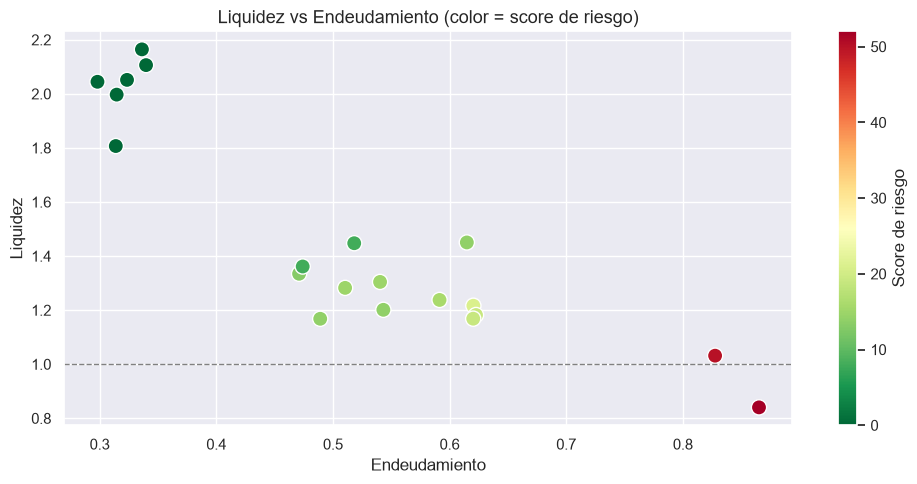

In [6]:
fig, ax = plt.subplots()
sc = ax.scatter(ult.endeudamiento, ult.liquidez, c=ult.score_riesgo,
                cmap="RdYlGn_r", s=120, edgecolor="white")
ax.axhline(1, color="gray", ls="--", lw=1)
ax.set_xlabel("Endeudamiento"); ax.set_ylabel("Liquidez")
ax.set_title("Liquidez vs Endeudamiento (color = score de riesgo)")
plt.colorbar(sc, label="Score de riesgo"); plt.tight_layout(); plt.show()

## 5. Conclusiones de negocio

- Las empresas en el cuadrante de **baja liquidez y alto endeudamiento** concentran el mayor riesgo.
- El **score compuesto** permite priorizar rapido la cartera para revision.
- **Accion recomendada:** revisar con prioridad las de score >= 65, complementar con flujo de caja y covenants antes de decisiones de credito.